# Entrega 2 — Detecção de Duplicatas

**Ouvidoria Inteligente: Triagem Semântica de Manifestações Cidadãs**
Aluno: Pedro Ernesto

Objetivo: construir `detectar_duplicatas(textos, limiar=0.85)` sobre embeddings, justificar o limiar, exibir a matriz de similaridade completa (heatmap), listar os pares detectados e analisar falsos positivos e falsos negativos contra o gabarito de duplicatas do dataset (`duplicatas_gabarito.json`).

In [1]:
import json
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

pd.set_option("display.max_colwidth", 110)
sns.set_theme(style="whitegrid")
Path("resultados").mkdir(exist_ok=True)

df = pd.read_json("manifestacoes.json")
ids = df["id"].tolist()
textos = df["texto"].tolist()

gabarito = {tuple(sorted(p)) for p in json.load(open("duplicatas_gabarito.json", encoding="utf-8"))["pares"]}
print(f"{len(df)} manifestações, {len(gabarito)} pares duplicados no gabarito ({2*len(gabarito)} manifestações envolvidas)")

40 manifestações, 6 pares duplicados no gabarito (12 manifestações envolvidas)


## 1. Embeddings e matriz de similaridade

In [2]:
MODELO_PRINCIPAL = "paraphrase-multilingual-MiniLM-L12-v2"
modelo = SentenceTransformer(MODELO_PRINCIPAL)
E = modelo.encode(textos, normalize_embeddings=True, show_progress_bar=False)
S = cosine_similarity(E)
print("matriz", S.shape)

matriz (40, 40)


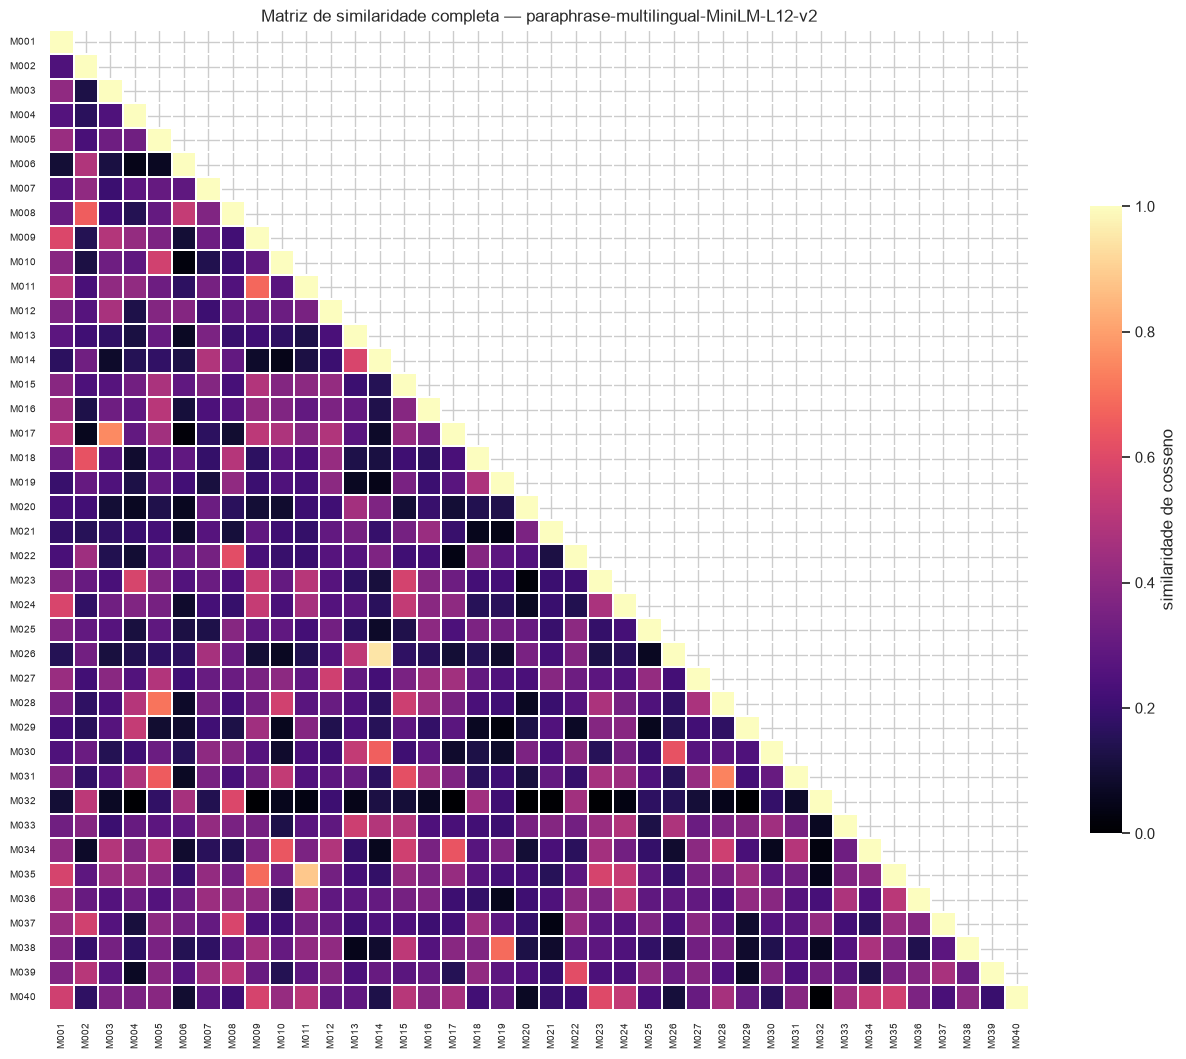

In [3]:
fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(S, dtype=bool), k=1)   # mostra só o triângulo inferior
sns.heatmap(S, mask=mask, xticklabels=ids, yticklabels=ids, cmap="magma", vmin=0, vmax=1,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.6, "label": "similaridade de cosseno"}, ax=ax)
ax.set_title(f"Matriz de similaridade completa — {MODELO_PRINCIPAL}")
plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig("resultados/heatmap_similaridade.png", dpi=130)

Como as 40 manifestações têm a diagonal igual a 1 e a matriz é simétrica, só o triângulo inferior está desenhado. Os pontos claros fora da diagonal são candidatos a duplicata.

Uma anotação com os valores numéricos deixaria o heatmap 40×40 ilegível; para ler os valores, o próximo passo lista os pares ordenados por similaridade.

## 2. A função `detectar_duplicatas`

In [4]:
def detectar_duplicatas(textos, limiar=0.85, modelo=None, ids=None, embeddings=None):
    """
    Retorna todos os pares (i, j, similaridade) com similaridade de cosseno >= limiar.

    Parâmetros
    ----------
    textos     : lista de strings (manifestações)
    limiar     : similaridade mínima para considerar duplicata
    modelo     : SentenceTransformer já carregado (default: MiniLM multilíngue)
    ids        : rótulos opcionais para os textos; se ausente, usa a posição
    embeddings : embeddings pré-calculados (evita recodificar em chamadas repetidas)

    Retorna
    -------
    DataFrame com colunas id_a, id_b, similaridade, ordenado da maior para a menor.
    """
    if embeddings is None:
        if modelo is None:
            modelo = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
        embeddings = modelo.encode(list(textos), normalize_embeddings=True, show_progress_bar=False)
    if ids is None:
        ids = list(range(len(textos)))

    S = cosine_similarity(embeddings)
    pares = [
        (ids[i], ids[j], float(S[i, j]))
        for i, j in combinations(range(len(textos)), 2)
        if S[i, j] >= limiar
    ]
    return (pd.DataFrame(pares, columns=["id_a", "id_b", "similaridade"])
              .sort_values("similaridade", ascending=False)
              .reset_index(drop=True))

dups_085 = detectar_duplicatas(textos, limiar=0.85, ids=ids, embeddings=E)
print(f"pares acima de 0.85: {len(dups_085)}")
dups_085

pares acima de 0.85: 2


,id_a,id_b,similaridade
0,M014,M026,0.948054
1,M011,M035,0.883999


## 3. Como escolher o limiar?

O enunciado sugere 0.85 como ponto de partida. Antes de aceitar esse valor, olho para a **distribuição** de todas as similaridades entre pares (780 pares para 40 manifestações). A intuição é que duplicatas reais devem formar uma cauda separada do "corpo" da distribuição.

média 0.284 | mediana 0.274 | p90 0.480 | p95 0.550 | p99 0.665
similaridade das duplicatas reais: [0.609 0.691 0.709 0.757 0.884 0.948]


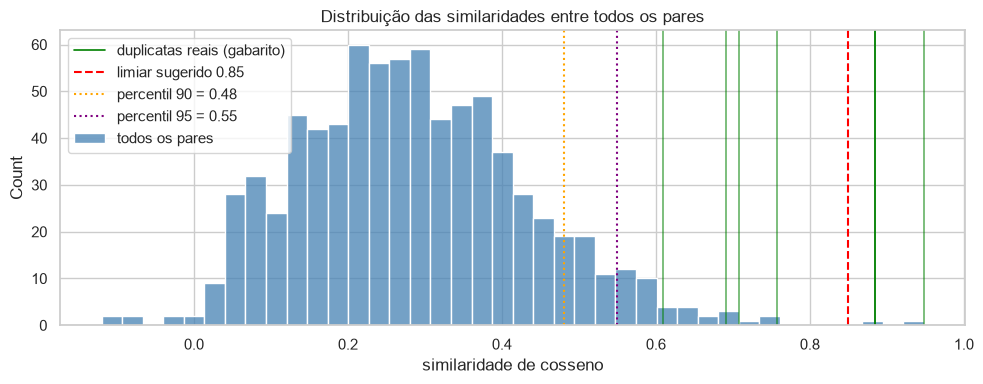

In [5]:
iu = np.triu_indices(len(df), k=1)
todas = S[iu]
p90, p95, p99 = np.percentile(todas, [90, 95, 99])

sims_gabarito = [S[ids.index(a), ids.index(b)] for a, b in gabarito]

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(todas, bins=40, ax=ax, color="steelblue", label="todos os pares")
for s in sims_gabarito:
    ax.axvline(s, color="green", alpha=0.6, lw=1.2)
ax.axvline(sims_gabarito[0], color="green", lw=1.2, label="duplicatas reais (gabarito)")
ax.axvline(0.85, color="red", ls="--", label="limiar sugerido 0.85")
ax.axvline(p90, color="orange", ls=":", label=f"percentil 90 = {p90:.2f}")
ax.axvline(p95, color="purple", ls=":", label=f"percentil 95 = {p95:.2f}")
ax.set(title="Distribuição das similaridades entre todos os pares", xlabel="similaridade de cosseno")
ax.legend()
plt.tight_layout()

print(f"média {todas.mean():.3f} | mediana {np.median(todas):.3f} | p90 {p90:.3f} | p95 {p95:.3f} | p99 {p99:.3f}")
print("similaridade das duplicatas reais:", np.round(sorted(sims_gabarito), 3))

Em seguida, avalio a função para uma grade de limiares comparando com o gabarito. As métricas são as clássicas de recuperação:

- **precisão** = pares detectados que são duplicatas reais / pares detectados;
- **revocação (recall)** = duplicatas reais detectadas / duplicatas reais;
- **F1** = média harmônica das duas.

Para a Ouvidoria, um falso negativo (duplicata que passa despercebida) custa retrabalho de um atendente; um falso positivo (duas manifestações diferentes fundidas) pode fazer um cidadão ficar sem resposta. Os dois erros importam, então o F1 é a métrica de escolha, com leve preferência por precisão.

Melhor F1: {'limiar': 0.7, 'precisão': 0.8, 'recall': 0.6666666666666666, 'F1': 0.7272727272727272, 'VP': 4.0, 'FP': 1.0, 'FN': 2.0}


,limiar,precisão,recall,F1,VP,FP,FN
0,0.500,0.095238,1.000000,0.173913,6,57,0
1,0.525,0.122449,1.000000,0.218182,6,43,0
2,0.550,0.153846,1.000000,0.266667,6,33,0
3,0.575,0.222222,1.000000,0.363636,6,21,0
4,0.600,0.333333,1.000000,0.500000,6,12,0
5,0.625,0.333333,0.833333,0.476190,5,10,1
6,0.650,0.454545,0.833333,0.588235,5,6,1
7,0.675,0.625000,0.833333,0.714286,5,3,1
8,0.700,0.800000,0.666667,0.727273,4,1,2
9,0.725,0.750000,0.500000,0.600000,3,1,3


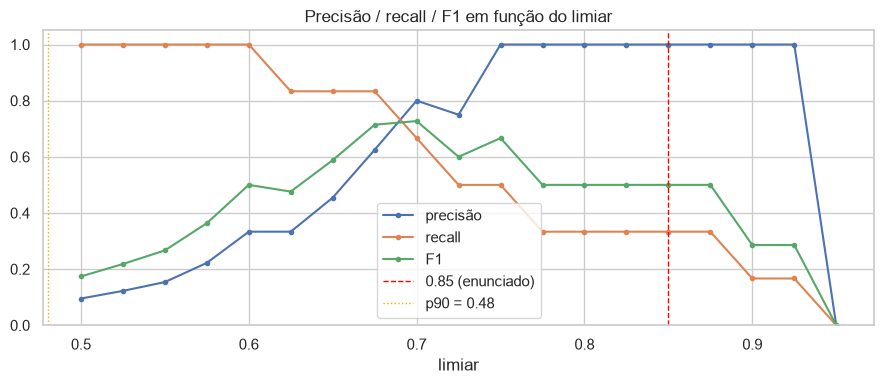

In [6]:
def avaliar(dups: pd.DataFrame, gabarito: set):
    previstos = {tuple(sorted((a, b))) for a, b in zip(dups["id_a"], dups["id_b"])}
    vp = previstos & gabarito
    fp = previstos - gabarito
    fn = gabarito - previstos
    prec = len(vp) / len(previstos) if previstos else 0.0
    rec = len(vp) / len(gabarito) if gabarito else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return {"precisão": prec, "recall": rec, "F1": f1, "VP": len(vp), "FP": len(fp), "FN": len(fn)}, fp, fn

grade = np.round(np.arange(0.50, 0.96, 0.025), 3)
linhas = []
for lim in grade:
    m, _, _ = avaliar(detectar_duplicatas(textos, limiar=lim, ids=ids, embeddings=E), gabarito)
    linhas.append({"limiar": lim, **m})
curva = pd.DataFrame(linhas)

ax = curva.plot(x="limiar", y=["precisão", "recall", "F1"], figsize=(9, 4), marker="o", ms=3)
ax.axvline(0.85, color="red", ls="--", lw=1, label="0.85 (enunciado)")
ax.axvline(p90, color="orange", ls=":", lw=1, label=f"p90 = {p90:.2f}")
ax.set(title="Precisão / recall / F1 em função do limiar", ylim=(0, 1.05)); ax.legend()
plt.tight_layout()

melhor = curva.loc[curva["F1"].idxmax()]
print("Melhor F1:", melhor.to_dict())
curva

In [7]:
# Se vários limiares empatam no F1 máximo, prefiro o mais alto (mais conservador = menos falsos positivos)
empates = curva[np.isclose(curva["F1"], curva["F1"].max())]
LIMIAR_FINAL = float(empates["limiar"].max())
print(f"Limiar escolhido: {LIMIAR_FINAL}  (faixa com F1 máximo: {empates['limiar'].min()}–{empates['limiar'].max()})")

Limiar escolhido: 0.7  (faixa com F1 máximo: 0.7–0.7)


**Justificativa do limiar.** O gráfico acima mostra onde o F1 é máximo. Neste corpus isso acontece em um único ponto da grade, 0.70 (F1 = 0.73: 4 acertos, 1 falso positivo, 2 falsos negativos), então a regra de desempate do código (preferir o limiar mais alto, porque entre soluções igualmente boas prefiro a mais conservadora, com menos fusões indevidas) não chegou a ser acionada. O valor 0.85 sugerido no enunciado fica bem acima disso: com ele o MiniLM detecta só 2 dos 6 pares do gabarito (recall 0.33), sem nenhum falso positivo. É restritivo demais para a escala de similaridade deste modelo e deixa duplicatas reais escaparem.

Também vale registrar o **limiar dinâmico** (percentil 90 da distribuição, dica 4 do enunciado). Ele tem a vantagem de se adaptar automaticamente a um novo modelo ou a um corpus com escala de similaridades diferente, sem recalibração manual. A desvantagem é assumir que ~10% dos pares são duplicatas, o que neste corpus (6 de 780 pares, ou 0.8%) é muito acima da realidade. Por isso, um percentil mais alto (p99) faz mais sentido como limiar dinâmico aqui.

## 4. Pares detectados com o limiar escolhido e análise de erros

In [8]:
dups_final = detectar_duplicatas(textos, limiar=LIMIAR_FINAL, ids=ids, embeddings=E)
metricas, fp, fn = avaliar(dups_final, gabarito)

dups_final["no gabarito?"] = [tuple(sorted((a, b))) in gabarito for a, b in zip(dups_final["id_a"], dups_final["id_b"])]
dups_final["texto_a"] = dups_final["id_a"].map(dict(zip(ids, textos))).str[:80] + "…"
dups_final["texto_b"] = dups_final["id_b"].map(dict(zip(ids, textos))).str[:80] + "…"
print(f"limiar {LIMIAR_FINAL}: {metricas}")
dups_final

limiar 0.7: {'precisão': 0.8, 'recall': 0.6666666666666666, 'F1': 0.7272727272727272, 'VP': 4, 'FP': 1, 'FN': 2}


,id_a,id_b,similaridade,no gabarito?,texto_a,texto_b
0,M014,M026,0.948054,True,A turma do 5º ano da escola municipal do bairro Valentina está sem professora de…,Os alunos do quinto ano da escola do Valentina estão há meses sem aula de portug…
1,M011,M035,0.883999,True,O caminhão do lixo não passa na rua Padre Meira há dez dias. Os sacos estão acum…,Coleta de lixo não está acontecendo na rua Padre Meira. Faz quase duas semanas q…
2,M003,M017,0.757315,True,"Tem um buraco enorme na Av. Brasil, na altura do número 1200, perto do supermerc…","O asfalto da avenida principal está todo esburacado, principalmente na Av. Brasi…"
3,M028,M031,0.741561,False,"Iluminação pública sem funcionar em toda a rua Manoel Deodato, no São José. Está…",A lâmpada do poste da praça do bairro Torre está queimada há mais de um mês. A p…
4,M005,M028,0.708511,True,"A rua onde moro, no bairro São José, está completamente escura porque os postes …","Iluminação pública sem funcionar em toda a rua Manoel Deodato, no São José. Está…"


In [9]:
texto_de = dict(zip(ids, textos))

def mostrar(pares, titulo):
    print(f"\n{'='*8} {titulo} ({len(pares)}) {'='*8}")
    for a, b in sorted(pares):
        s = S[ids.index(a), ids.index(b)]
        print(f"\n[{a} × {b}]  sim = {s:.3f}")
        print(f"  {a}: {texto_de[a]}")
        print(f"  {b}: {texto_de[b]}")

mostrar(fp, "FALSOS POSITIVOS (detectados, mas não são duplicatas)")
mostrar(fn, "FALSOS NEGATIVOS (duplicatas reais não detectadas)")


======== FALSOS POSITIVOS (detectados, mas não são duplicatas) (1) ========

[M028 × M031]  sim = 0.742
  M028: Iluminação pública sem funcionar em toda a rua Manoel Deodato, no São José. Está escuro demais à noite e os moradores têm medo de sair, já ocorreram assaltos.
  M031: A lâmpada do poste da praça do bairro Torre está queimada há mais de um mês. A praça fica toda escura e as pessoas pararam de frequentar à noite.

======== FALSOS NEGATIVOS (duplicatas reais não detectadas) (2) ========

[M008 × M022]  sim = 0.609
  M008: O posto de saúde do bairro Geisel está sem médico há duas semanas. Chegamos às 5 da manhã, pegamos ficha e depois avisam que não vai ter atendimento.
  M022: Falta atendimento no PSF do Geisel. Faz quinze dias que nenhum profissional aparece na unidade; a gente madruga na fila, pega senha e volta pra casa sem consulta.

[M019 × M038]  sim = 0.691
  M019: Fui assaltada no ponto de ônibus da avenida Pedro II, em frente à farmácia, por volta das 19h. Dois homens 

### Leitura dos erros

- **Falso positivo** (M028 × M031, sim. 0.74): duas reclamações de iluminação pública em bairros distintos (rua Manoel Deodato, no São José, e praça da Torre), ou seja, o *mesmo tipo* de problema em lugares diferentes. Para o modelo elas são paráfrases; para a Ouvidoria são chamados diferentes, porque o endereço muda. É uma limitação intrínseca de embeddings semânticos: eles capturam "o que" e não "onde". Uma correção prática é combinar o score semântico com um filtro de entidade (bairro, rua) extraído por regex ou NER.
- **Falsos negativos** (M008 × M022, sim. 0.61; M019 × M038, sim. 0.69): são textos curtos e de tamanho parecido, então não é um problema de diluição por tamanho. O que muda entre as duas versões é o vocabulário (posto de saúde/PSF, médico/profissional, ficha/senha; assaltada/roubos, ponto/parada) e o ponto de vista: uma versão relata um episódio pessoal, a outra descreve o problema como recorrente e pede providência. O MiniLM percebe a relação (os dois pares ficam acima do percentil 95 da distribuição, 0.55), mas não com força para passar do limiar; o mpnet dá 0.73 a M008 × M022. Para esses casos o ganho vem de um modelo maior, ou de um limiar menor combinado com um filtro de local, e não do chunking, que só faz sentido para textos longos.

A seção seguinte checa se um modelo maior muda o quadro.

## 5. Comparação com um segundo modelo

In [10]:
MODELO_2 = "paraphrase-multilingual-mpnet-base-v2"
modelo2 = SentenceTransformer(MODELO_2)
E2 = modelo2.encode(textos, normalize_embeddings=True, show_progress_bar=False)

comparacao = []
for nome, emb in [(MODELO_PRINCIPAL, E), (MODELO_2, E2)]:
    for lim in [0.85, LIMIAR_FINAL, float(np.percentile(cosine_similarity(emb)[iu], 99))]:
        m, _, _ = avaliar(detectar_duplicatas(textos, limiar=lim, ids=ids, embeddings=emb), gabarito)
        comparacao.append({"modelo": nome.split("/")[-1], "limiar": round(lim, 3), **{k: round(v, 3) if isinstance(v, float) else v for k, v in m.items()}})
tabela_modelos = pd.DataFrame(comparacao)
tabela_modelos

,modelo,limiar,precisão,recall,F1,VP,FP,FN
0,paraphrase-multilingual-MiniLM-L12-v2,0.850,1.000,0.333,0.500,2,0,4
1,paraphrase-multilingual-MiniLM-L12-v2,0.700,0.800,0.667,0.727,4,1,2
2,paraphrase-multilingual-MiniLM-L12-v2,0.665,0.625,0.833,0.714,5,3,1
3,paraphrase-multilingual-mpnet-base-v2,0.850,1.000,0.500,0.667,3,0,3
4,paraphrase-multilingual-mpnet-base-v2,0.700,0.545,1.000,0.706,6,5,0
5,paraphrase-multilingual-mpnet-base-v2,0.740,0.625,0.833,0.714,5,3,1


Como as escalas de similaridade mudam de um modelo para outro (um modelo pode ser "mais generoso" que o outro para pares não relacionados), o mesmo limiar fixo não é diretamente transferível. É exatamente o cenário em que o limiar dinâmico por percentil (última linha de cada modelo) ajuda: ele se ajusta à escala do modelo sem intervenção manual.

## 6. Persistência dos resultados

In [11]:
resultados = {
    "modelo": MODELO_PRINCIPAL,
    "limiar_final": LIMIAR_FINAL,
    "faixa_f1_max": [float(empates["limiar"].min()), float(empates["limiar"].max())],
    "percentis": {"p90": float(p90), "p95": float(p95), "p99": float(p99)},
    "distribuicao": {"media": float(todas.mean()), "mediana": float(np.median(todas))},
    "metricas_limiar_final": metricas,
    "metricas_085": avaliar(dups_085, gabarito)[0],
    "falsos_positivos": [list(p) for p in sorted(fp)],
    "falsos_negativos": [list(p) for p in sorted(fn)],
    "pares_detectados": dups_final[["id_a", "id_b", "similaridade"]].round(3).to_dict(orient="records"),
    "comparacao_modelos": tabela_modelos.to_dict(orient="records"),
    "sims_gabarito": {f"{a}-{b}": float(S[ids.index(a), ids.index(b)]) for a, b in sorted(gabarito)},
}
with open("resultados/entrega2.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)
print("salvo em resultados/entrega2.json")

salvo em resultados/entrega2.json
